/Users/aditya/.pyenv/versions/3.12.0/lib/python3.12/site-packages/mesa/mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)



Final model row:
                               900
effective_studio_cost   702.165209
studio_units           1326.000000
shared_units           1574.000000
studio_rent             702.165209
shared_rent             515.195133
students_in_studio      912.000000
students_in_shared     1066.000000
students_unhoused        22.000000
share_matched             0.869500
avg_mismatch              0.130500
avg_loneliness            0.665471
studio_allowance_cost     0.000000
total_public_cost         0.000000
vacancy_studio            0.312217
vacancy_shared            0.322745
withdrawn_studios         0.000000
withdrawn_shared          0.000000
built_studios             2.000000
built_shared              1.000000
scarcity_studio           0.192308
scarcity_shared           0.003812


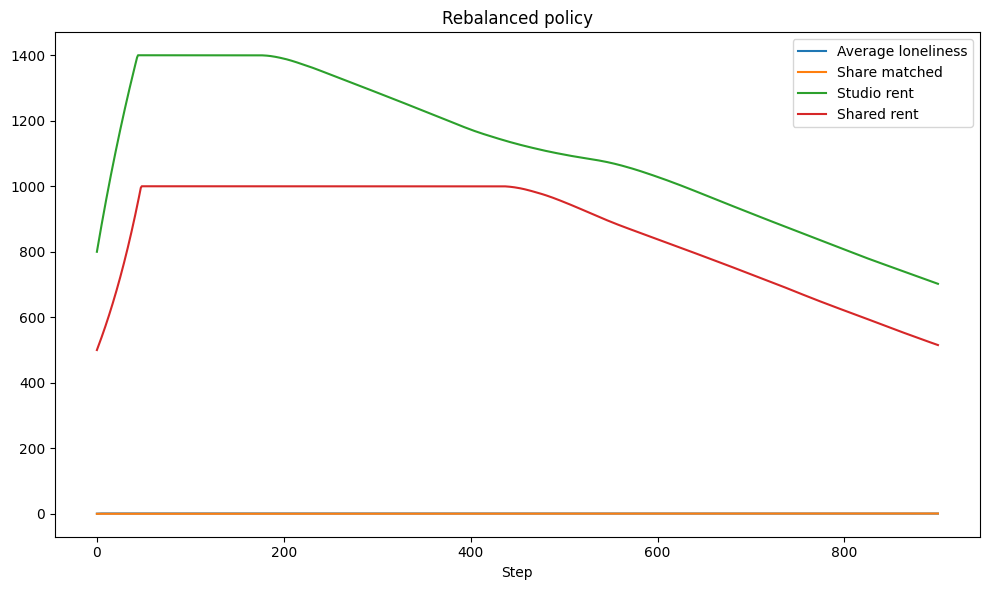

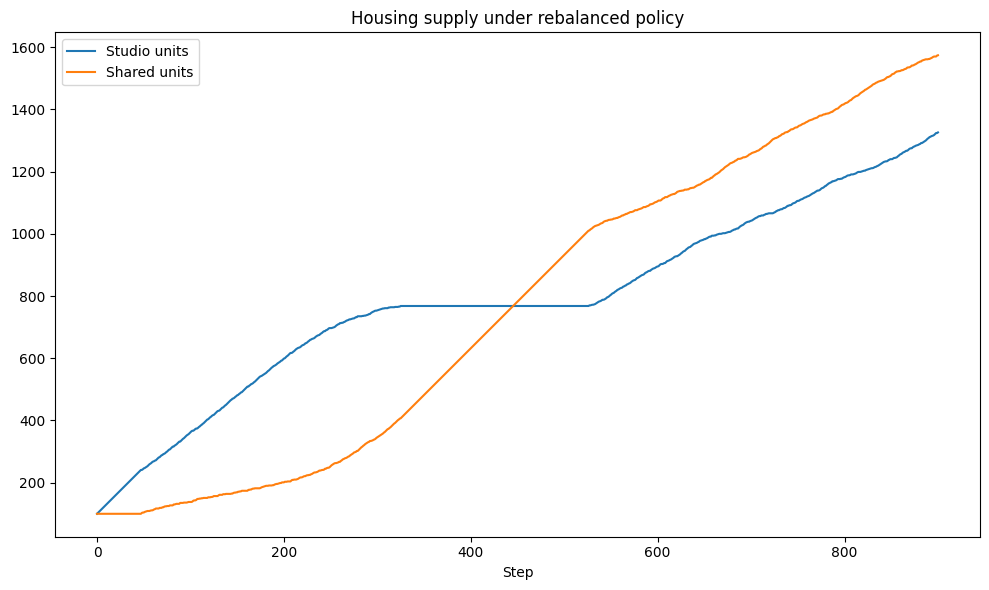

/Users/aditya/.pyenv/versions/3.12.0/lib/python3.12/site-packages/mesa/mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)
/Users/aditya/.pyenv/versions/3.12.0/lib/python3.12/site-packages/mesa/mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)



Scenario comparison:
                 scenario  studio_units  shared_units  studio_rent  \
0   studio_subsidy_absent         190.0         111.0   679.731141   
1  studio_subsidy_present         100.0          79.0   626.927409   

   shared_rent  effective_studio_cost  students_in_studio  students_in_shared  \
0   430.744680             679.731141               149.0               126.0   
1   435.730031             426.927409               174.0               126.0   

   students_unhoused  share_matched  avg_mismatch  avg_loneliness  \
0               25.0       0.916667      0.083333        0.593333   
1                0.0       1.000000      0.000000        0.593333   

   total_public_cost  
0                0.0  
1            34800.0  


In [34]:
from __future__ import annotations

from typing import Optional

import matplotlib.pyplot as plt
import pandas as pd
import mesa
from mesa.datacollection import DataCollector


# =========================================================
# STUDENT AGENT
# =========================================================

class StudentAgent(mesa.Agent):
    """
    Student agent in a non-spatial housing market.

    Key idea:
    - each student has a preferred housing type
    - each step they must choose the best feasible option available now
    - loneliness evolves from mismatch, isolation, and financial stress
    """

    def __init__(
        self,
        model: "StudentHousingModel",
        income: float,
        privacy_pref: float,
        social_need: float,
        time_pressure: float,
        loneliness_sensitivity: float,
        stress_sensitivity: float,
    ):
        super().__init__(model)

        self.income = income
        self.privacy_pref = privacy_pref
        self.social_need = social_need
        self.time_pressure = time_pressure
        self.loneliness_sensitivity = loneliness_sensitivity
        self.stress_sensitivity = stress_sensitivity

        self.housing_preference = (
            "shared" if self.social_need - self.privacy_pref > 0.1 else "studio"
        )

        self.current_housing = "none"
        self.mismatch = 0.0
        self.loneliness = 0.4

        # useful for diagnostics
        self.last_choice_utility_studio = None
        self.last_choice_utility_shared = None

    def step(self) -> None:
        """
        Students do not automatically re-enter the housing market every step.
        If already housed, they may stay unless mismatched and willing/able to move.
        """

        # If already housed and matched, stay put
        if self.current_housing != "none" and self.current_housing == self.housing_preference:
            if self.current_housing == "studio":
                self.model.realized_demand_studio += 1
            elif self.current_housing == "shared":
                self.model.realized_demand_shared += 1
            return

        # If already housed but mismatched, only some try to move
        if self.current_housing != "none" and self.current_housing != self.housing_preference:
            if self.model.random.random() > self.model.move_probability:
                if self.current_housing == "studio":
                    self.model.realized_demand_studio += 1
                elif self.current_housing == "shared":
                    self.model.realized_demand_shared += 1
                return

        # If unhoused, or if mismatched and trying to move, choose housing
        old_housing = self.current_housing
        choice = self.choose_housing()

        # Free up old unit if moving away from it
        if old_housing == "studio" and choice != "studio":
            self.model.available_studios += 1
        elif old_housing == "shared" and choice != "shared":
            self.model.available_shared += 1

        # Allocate new unit
        if choice == "studio" and self.model.available_studios > 0:
            self.current_housing = "studio"
            self.model.available_studios -= 1
            self.model.realized_demand_studio += 1

        elif choice == "shared" and self.model.available_shared > 0:
            self.current_housing = "shared"
            self.model.available_shared -= 1
            self.model.realized_demand_shared += 1

        else:
            self.current_housing = "none"
            self.model.realized_unhoused += 1

    def choose_housing(self) -> str:
        options: dict[str, float] = {}

        self.last_choice_utility_studio = None
        self.last_choice_utility_shared = None

        # Studio
        if self.model.available_studios > 0:
            effective_studio_cost = max(
                self.model.studio_rent - self.model.studio_rent_allowance,
                0.0,
            )
            if effective_studio_cost <= self.income:
                u_studio = self.utility_studio(effective_studio_cost)
                options["studio"] = u_studio
                self.last_choice_utility_studio = u_studio

        # Shared
        if self.model.available_shared > 0:
            effective_shared_cost = self.model.shared_rent
            if effective_shared_cost <= self.income:
                u_shared = self.utility_shared(effective_shared_cost)
                options["shared"] = u_shared
                self.last_choice_utility_shared = u_shared

        # Forced-choice constraint:
        # if at least one real option exists, choose the best one.
        if options:
            return max(options, key=options.get)

        # Only fallback if nothing is feasible.
        return "none"

    def utility_studio(self, cost: float) -> float:
        affordability = -cost / max(self.income, 1.0)
        preference_fit = 1.0 if self.housing_preference == "studio" else -0.6
        privacy_benefit = self.privacy_pref
        social_penalty = -0.8 * self.social_need
        scarcity_penalty = -0.20 * self.model.scarcity_studio
        time_bonus = 0.10 * self.time_pressure

        return (
            1.25 * affordability
            + 1.0 * preference_fit
            + 0.8 * privacy_benefit
            + social_penalty
            + scarcity_penalty
            + time_bonus
        )

    def utility_shared(self, cost: float) -> float:
        affordability = -cost / max(self.income, 1.0)
        preference_fit = 1.0 if self.housing_preference == "shared" else -0.6
        social_benefit = self.social_need
        privacy_penalty = -0.7 * self.privacy_pref
        scarcity_penalty = -0.20 * self.model.scarcity_shared
        coordination_penalty = -0.08 * self.time_pressure

        return (
            1.25 * affordability
            + 1.0 * preference_fit
            + social_benefit
            + privacy_penalty
            + scarcity_penalty
            + coordination_penalty
        )

    def advance_wellbeing(self) -> None:
        """
        Loneliness update after housing allocation.
        """
        self.mismatch = 0.0 if self.current_housing == self.housing_preference else 1.0

        if self.current_housing == "studio":
            housing_cost = max(
                self.model.studio_rent - self.model.studio_rent_allowance,
                0.0,
            )
            isolation = 0.5
            routine_interaction = 0.10

        elif self.current_housing == "shared":
            housing_cost = self.model.shared_rent
            isolation = 0.10
            routine_interaction = 0.5

        else:
            housing_cost = self.income * 0.5
            isolation = 0.5
            routine_interaction = 0.02

        rent_burden = housing_cost / max(self.income, 1.0)
        stress = max(rent_burden - 0.35, 0.0)

        delta = (
            0.12 * self.loneliness_sensitivity * self.mismatch
            + 0.10 * isolation
            + 0.10 * self.stress_sensitivity * stress
            - 0.12 * routine_interaction
        )

        self.loneliness = min(max(self.loneliness + delta, 0.0), 1.0)


# =========================================================
# MODEL
# =========================================================

class StudentHousingModel(mesa.Model):
    """
    Mesa ABM for student housing and loneliness with:

    - forced short-term housing choice
    - endogenous rents
    - developer entry/build response
    - investor withdrawal when profitability is negative
    """

    def __init__(
        self,
        n_students: int = 300,
        initial_studios: int = 120,
        move_probability: float = 0.25,
        initial_shared: int = 90,
        studio_rent: float = 750.0,
        shared_rent: float = 500.0,
        studio_operating_cost: float = 680.0,
        shared_operating_cost: float = 470.0,
        studio_build_cost: float = 720.0,
        shared_build_cost: float = 520.0,
        studio_rent_allowance: float = 300.0,
        developer_build_rate: int = 8,
        investor_withdrawal_rate: float = 0.05,
        rent_adjustment_speed: float = 0.08,
        vacancy_sensitivity: float = 0.06,
        min_studio_rent: float = 400.0,
        max_studio_rent: float = 1400.0,
        min_shared_rent: float = 250.0,
        max_shared_rent: float = 1000.0,
        seed: Optional[int] = 42,
    ):
        super().__init__(seed=seed)

        # -----------------------------
        # Stock
        # -----------------------------
        self.studio_units = initial_studios
        self.shared_units = initial_shared

        # -----------------------------
        # Prices
        # -----------------------------
        self.studio_rent = studio_rent
        self.shared_rent = shared_rent

        self.min_studio_rent = min_studio_rent
        self.max_studio_rent = max_studio_rent
        self.min_shared_rent = min_shared_rent
        self.max_shared_rent = max_shared_rent

        self.rent_adjustment_speed = rent_adjustment_speed
        self.vacancy_sensitivity = vacancy_sensitivity

        # -----------------------------
        # Cost structure
        # -----------------------------
        self.studio_operating_cost = studio_operating_cost
        self.shared_operating_cost = shared_operating_cost
        self.studio_build_cost = studio_build_cost
        self.shared_build_cost = shared_build_cost

        # -----------------------------
        # Policy
        # -----------------------------
        self.studio_rent_allowance = studio_rent_allowance
        self.developer_build_rate = developer_build_rate
        self.investor_withdrawal_rate = investor_withdrawal_rate

        # -----------------------------
        # Dynamic counters
        # -----------------------------
        self.available_studios = self.studio_units
        self.available_shared = self.shared_units

        self.scarcity_studio = 0.0
        self.scarcity_shared = 0.0

        self.realized_demand_studio = 0
        self.realized_demand_shared = 0
        self.realized_unhoused = 0

        self.last_vacancy_studio = 0.0
        self.last_vacancy_shared = 0.0

        self.last_withdrawn_studios = 0
        self.last_withdrawn_shared = 0
        self.last_built_studios = 0
        self.last_built_shared = 0

        # Previous-step latent demand proxies
        self.latency_demand_studio = initial_studios
        self.latency_demand_shared = initial_shared

        self.move_probability = move_probability

        # -----------------------------
        # Create student agents
        # -----------------------------
        for _ in range(n_students):
            income = self.random.uniform(500, 1400)
            privacy_pref = self.random.uniform(0.0, 1.0)
            social_need = self.random.uniform(0.0, 1.0)
            time_pressure = self.random.uniform(0.0, 1.0)
            loneliness_sensitivity = self.random.uniform(0.6, 1.4)
            stress_sensitivity = self.random.uniform(0.6, 1.4)

            StudentAgent(
                self,
                income=income,
                privacy_pref=privacy_pref,
                social_need=social_need,
                time_pressure=time_pressure,
                loneliness_sensitivity=loneliness_sensitivity,
                stress_sensitivity=stress_sensitivity,
            )

        # -----------------------------
        # Data collection
        # -----------------------------
        self.datacollector = DataCollector(
            model_reporters={
                "effective_studio_cost": lambda m: m.studio_rent - m.studio_rent_allowance,
                "studio_units": lambda m: m.studio_units,
                "shared_units": lambda m: m.shared_units,
                "studio_rent": lambda m: m.studio_rent,
                "shared_rent": lambda m: m.shared_rent,
                "students_in_studio": lambda m: m.count_housing("studio"),
                "students_in_shared": lambda m: m.count_housing("shared"),
                "students_unhoused": lambda m: m.count_housing("none"),
                "share_matched": lambda m: m.share_matched(),
                "avg_mismatch": lambda m: m.avg_mismatch(),
                "avg_loneliness": lambda m: m.avg_loneliness(),
                "studio_allowance_cost": lambda m: m.studio_allowance_cost(),
                "total_public_cost": lambda m: m.total_public_cost(),
                "vacancy_studio": lambda m: m.last_vacancy_studio,
                "vacancy_shared": lambda m: m.last_vacancy_shared,
                "withdrawn_studios": lambda m: m.last_withdrawn_studios,
                "withdrawn_shared": lambda m: m.last_withdrawn_shared,
                "built_studios": lambda m: m.last_built_studios,
                "built_shared": lambda m: m.last_built_shared,
                "scarcity_studio": lambda m: m.scarcity_studio,
                "scarcity_shared": lambda m: m.scarcity_shared,
            },
            agent_reporters={
                "housing_preference": "housing_preference",
                "current_housing": "current_housing",
                "mismatch": "mismatch",
                "loneliness": "loneliness",
                "income": "income",
            },
        )

        self.datacollector.collect(self)

    # =====================================================
    # MAIN STEP
    # =====================================================

    def step(self) -> None:
        # Reset counters
        self.realized_demand_studio = 0
        self.realized_demand_shared = 0
        self.realized_unhoused = 0
        self.last_withdrawn_studios = 0
        self.last_withdrawn_shared = 0
        self.last_built_studios = 0
        self.last_built_shared = 0

        # 1. Investors withdraw unprofitable units
        self.investor_withdrawal()

        # 2. Developers build based on expected profitability
        self.developer_build_decision()

        # 3. Only vacant units are available for this step's allocation
        occupied_studios = self.count_housing("studio")
        occupied_shared = self.count_housing("shared")

        self.available_studios = max(self.studio_units - occupied_studios, 0)
        self.available_shared = max(self.shared_units - occupied_shared, 0)

        # 4. Students choose housing in random order
        self.agents.shuffle_do("step")

        # 5. Update scarcity and vacancy
        self.update_market_state()

        # 6. Endogenous rent adjustment
        self.adjust_rents()

        # 7. Update wellbeing
        for agent in self.agents:
            agent.advance_wellbeing()

        # 8. Collect data
        self.datacollector.collect(self)

    # =====================================================
    # MARKET DYNAMICS
    # =====================================================

    def studio_profit_margin(self) -> float:
        """
        Simplified per-unit operational margin for investors.
        """
        return self.studio_rent - self.studio_operating_cost

    def shared_profit_margin(self) -> float:
        """
        Shared units benefit from object subsidy on the supply side.
        """
        return self.shared_rent - self.shared_operating_cost

    def investor_withdrawal(self) -> None:
        """
        Investors remove units if operating margins are negative.
        """
        studio_margin = self.studio_profit_margin()
        shared_margin = self.shared_profit_margin()

        if studio_margin < 0 and self.studio_units > 0:
            removed = max(1, int(self.studio_units * self.investor_withdrawal_rate))
            self.studio_units = max(self.studio_units - removed, 0)
            self.last_withdrawn_studios = removed

        if shared_margin < 0 and self.shared_units > 0:
            removed = max(1, int(self.shared_units * self.investor_withdrawal_rate))
            self.shared_units = max(self.shared_units - removed, 0)
            self.last_withdrawn_shared = removed

    def developer_build_decision(self) -> None:
        """
        Developers compare expected profitability and add units.
        Includes:
        - operating margin
        - mild demand signal
        - mild occupancy signal
        - policy effects
        """
        occupancy_studio = self.count_housing("studio") / max(self.studio_units, 1)
        occupancy_shared = self.count_housing("shared") / max(self.shared_units, 1)

        demand_pressure_studio = self.latency_demand_studio / max(self.studio_units, 1)
        demand_pressure_shared = self.latency_demand_shared / max(self.shared_units, 1)

        expected_studio_return = (
            self.studio_rent
            - self.studio_build_cost
            + 80.0 * occupancy_studio
            + 60.0 * demand_pressure_studio
        )

        expected_shared_return = (
            self.shared_rent
            - self.shared_build_cost
            + 80.0 * occupancy_shared
            + 60.0 * demand_pressure_shared
        )

        for _ in range(self.developer_build_rate):
            studio_signal = expected_studio_return + self.random.uniform(-10.0, 10.0)
            shared_signal = expected_shared_return + self.random.uniform(-10.0, 10.0)

            if studio_signal > 0 and studio_signal > shared_signal:
                self.studio_units += 1
                self.last_built_studios += 1

            elif shared_signal > 0 and shared_signal > studio_signal:
                self.shared_units += 1
                self.last_built_shared += 1

    def update_market_state(self) -> None:
        """
        Update scarcity, vacancy, and latent demand proxies after allocation.
        """
        occupied_studios = self.count_housing("studio")
        occupied_shared = self.count_housing("shared")

        self.last_vacancy_studio = max(self.studio_units - occupied_studios, 0) / max(
            self.studio_units, 1
        )
        self.last_vacancy_shared = max(self.shared_units - occupied_shared, 0) / max(
            self.shared_units, 1
        )

        unmet_studio = sum(
            1
            for a in self.agents
            if a.housing_preference == "studio" and a.current_housing != "studio"
        )
        unmet_shared = sum(
            1
            for a in self.agents
            if a.housing_preference == "shared" and a.current_housing != "shared"
        )

        self.scarcity_studio = unmet_studio / max(self.studio_units, 1)
        self.scarcity_shared = unmet_shared / max(self.shared_units, 1)

        # latent demand proxy carried into next round
        self.latency_demand_studio = occupied_studios + unmet_studio
        self.latency_demand_shared = occupied_shared + unmet_shared

    def adjust_rents(self) -> None:
        """
        Endogenous rent update.

        Rent rises with scarcity / unmet demand and falls with vacancy.
        This is intentionally simple but closes the core market feedback loop.
        """
        studio_growth = (
            self.rent_adjustment_speed * self.scarcity_studio
            - self.vacancy_sensitivity * self.last_vacancy_studio
        )
        shared_growth = (
            self.rent_adjustment_speed * self.scarcity_shared
            - self.vacancy_sensitivity * self.last_vacancy_shared
        )

        target_studio_rent = self.studio_rent * (1.0 + studio_growth)
        target_shared_rent = self.shared_rent * (1.0 + shared_growth)

        inertia = 0.2
        self.studio_rent = (1 - inertia) * self.studio_rent + inertia * target_studio_rent
        self.shared_rent = (1 - inertia) * self.shared_rent + inertia * target_shared_rent

        self.studio_rent = min(max(self.studio_rent, self.min_studio_rent), self.max_studio_rent)
        self.shared_rent = min(max(self.shared_rent, self.min_shared_rent), self.max_shared_rent)

    # =====================================================
    # METRICS
    # =====================================================

    def count_housing(self, housing_type: str) -> int:
        return sum(1 for a in self.agents if a.current_housing == housing_type)

    def share_matched(self) -> float:
        return sum(
            1 for a in self.agents if a.current_housing == a.housing_preference
        ) / max(len(self.agents), 1)

    def avg_mismatch(self) -> float:
        return sum(a.mismatch for a in self.agents) / max(len(self.agents), 1)

    def avg_loneliness(self) -> float:
        return sum(a.loneliness for a in self.agents) / max(len(self.agents), 1)

    def studio_allowance_cost(self) -> float:
        return self.count_housing("studio") * self.studio_rent_allowance

    def total_public_cost(self) -> float:
        return self.studio_allowance_cost()


# =========================================================
# HELPERS
# =========================================================

def run_model(
    steps: int = 40,
    **model_kwargs,
) -> tuple[StudentHousingModel, pd.DataFrame, pd.DataFrame]:
    model = StudentHousingModel(**model_kwargs)

    for _ in range(steps):
        model.step()

    model_df = model.datacollector.get_model_vars_dataframe()
    agent_df = model.datacollector.get_agent_vars_dataframe()
    return model, model_df, agent_df


def scenario_dict() -> dict[str, dict]:
    return {
        "studio_subsidy_absent": {
            "studio_rent_allowance": 0.0,
        },
        "studio_subsidy_present": {
            "studio_rent_allowance": 200,
        },
    }


def compare_scenarios(steps: int = 40) -> pd.DataFrame:
    rows = []

    for scenario_name, params in scenario_dict().items():
        _, model_df, _ = run_model(
            steps=steps,
            seed=42,
            **params,
        )

        final = model_df.iloc[-1].to_dict()
        final["scenario"] = scenario_name
        rows.append(final)

    if not rows:
        raise ValueError("No scenarios found. Check that scenario_dict() returns a non-empty dictionary.")

    comparison = pd.DataFrame(rows)

    cols = [
        "scenario",
        "studio_units",
        "shared_units",
        "studio_rent",
        "shared_rent",
        "effective_studio_cost",
        "students_in_studio",
        "students_in_shared",
        "students_unhoused",
        "share_matched",
        "avg_mismatch",
        "avg_loneliness",
        "total_public_cost",
    ]

    return comparison[[c for c in cols if c in comparison.columns]]


def plot_model_trajectory(model_df: pd.DataFrame, title: str = "Model trajectory") -> None:
    plt.figure(figsize=(10, 6))
    plt.plot(model_df.index, model_df["avg_loneliness"], label="Average loneliness")
    plt.plot(model_df.index, model_df["share_matched"], label="Share matched")
    plt.plot(model_df.index, model_df["studio_rent"], label="Studio rent")
    plt.plot(model_df.index, model_df["shared_rent"], label="Shared rent")
    plt.xlabel("Step")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_supply_trajectory(model_df: pd.DataFrame, title: str = "Housing supply") -> None:
    plt.figure(figsize=(10, 6))
    plt.plot(model_df.index, model_df["studio_units"], label="Studio units")
    plt.plot(model_df.index, model_df["shared_units"], label="Shared units")
    plt.xlabel("Step")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# EXAMPLE USAGE
# =========================================================

if __name__ == "__main__":
    # Single scenario run
    model, model_df, agent_df = run_model(
        steps=900,
        n_students=2000,
        initial_studios=100,
        initial_shared=100,
        studio_rent=800,
        shared_rent=500.0,
        studio_operating_cost=500,
        shared_operating_cost=500,
        studio_build_cost=720.0,
        shared_build_cost=520.0,
        studio_rent_allowance=0,
        developer_build_rate=3,
        investor_withdrawal_rate=0.2,
        rent_adjustment_speed=0.01,
        vacancy_sensitivity=0.03,
        seed=42,
    )

    print("\nFinal model row:")
    print(model_df.tail(1).T)

    plot_model_trajectory(model_df, title="Rebalanced policy")
    plot_supply_trajectory(model_df, title="Housing supply under rebalanced policy")

    comparison = compare_scenarios(steps=900)
    print("\nScenario comparison:")
    print(comparison)